# Testing the Effectiveness of a Campaign on Questionnaire Responsiveness

In [296]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, ttest_rel
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

In [297]:
# Upoad data
df = pd.read_csv("AdSmartABdata - AdSmartABdata.csv")

# Preliminary analysis

In [298]:
df.head()

,auction_id,experiment,date,hour,device_make,platform_os,browser,yes,no
0,0008ef63-77a7-448b-bd1e-075f42c55e39,exposed,2020-07-10,8,Generic Smartphone,6,Chrome Mobile,0,0
1,000eabc5-17ce-4137-8efe-44734d914446,exposed,2020-07-07,10,Generic Smartphone,6,Chrome Mobile,0,0
2,0016d14a-ae18-4a02-a204-6ba53b52f2ed,exposed,2020-07-05,2,E5823,6,Chrome Mobile WebView,0,1
3,00187412-2932-4542-a8ef-3633901c98d9,control,2020-07-03,15,Samsung SM-A705FN,6,Facebook,0,0
4,001a7785-d3fe-4e11-a344-c8735acacc2c,control,2020-07-03,15,Generic Smartphone,6,Chrome Mobile,0,0


In [299]:
df.describe()

,hour,platform_os,yes,no
count,8077.000000,8077.000000,8077.000000,8077.000000
mean,11.615080,5.947134,0.070818,0.083075
std,5.734879,0.224333,0.256537,0.276013
min,0.000000,5.000000,0.000000,0.000000
25%,7.000000,6.000000,0.000000,0.000000
50%,13.000000,6.000000,0.000000,0.000000
75%,15.000000,6.000000,0.000000,0.000000
max,23.000000,7.000000,1.000000,1.000000


In [300]:
# Missing data
df[df.isnull().any(axis=1)]

,auction_id,experiment,date,hour,device_make,platform_os,browser,yes,no


In [301]:
# Coarsen multi-category data 
df['device_make'] = df['device_make'].str.split().str[0]

In [302]:
df['time_of_day'] = pd.cut(df['hour'],
    bins=[0,6,12,18,24],
    labels=['night', 'morning', 'afternoon', 'evening'],
    right=False
)

# Balanced data check

## Group sizes

In [303]:
df['experiment'].value_counts()

experiment
control    4071
exposed    4006
Name: count, dtype: int64

## Resposes over time

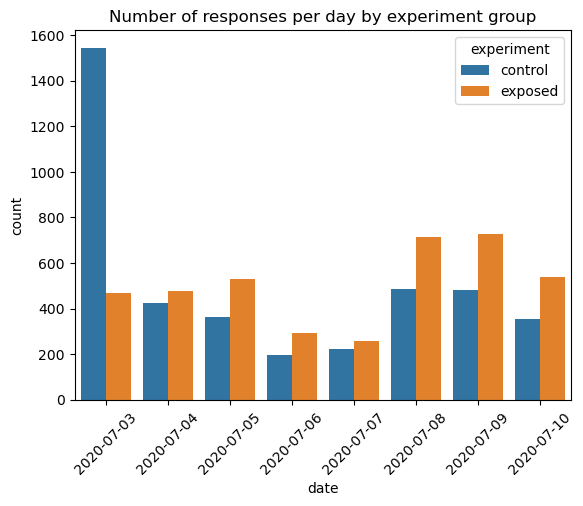

In [304]:
daily_counts = df.groupby(['date', 'experiment']).size().reset_index(name='count')
sns.barplot(daily_counts, x='date', y='count', hue = 'experiment')
plt.title("Number of responses per day by experiment group")
plt.xticks(rotation = 45)
plt.show()

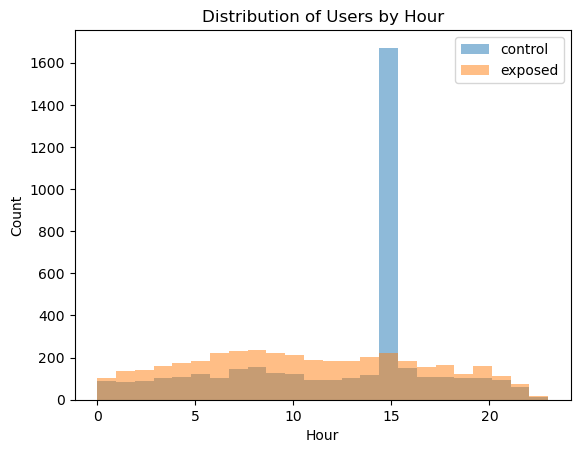

In [356]:
df.groupby('experiment')['hour'].value_counts(normalize=True)['control']
plt.hist(df[df['experiment'] == 'control']['hour'], bins=24, alpha=0.5, label='control')
plt.hist(df[df['experiment'] == 'exposed']['hour'], bins=24, alpha=0.5, label='exposed')
plt.xlabel("Hour")
plt.ylabel("Count")
plt.title('Distribution of Users by Hour')
plt.legend()
plt.show()

Both date and a time of the day impacts the assignments to the groups. The strongly unbalanced day (2020-07-03) and hour (3 p.m.) might invalidate your A/B test, and we should check why it’s unbalanced. Adjustment for the biases is needed.

## Browsers used across the groups

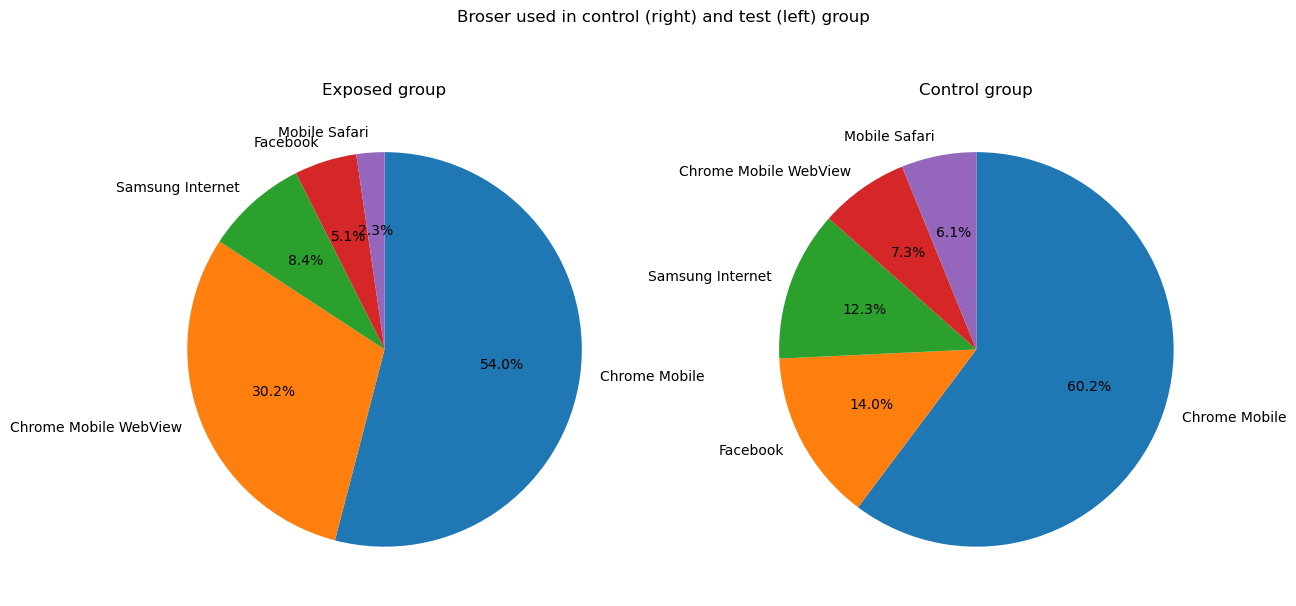

In [305]:
# Dummy Variable for 'experiment'
df['dummy_experiment'] = np.where(df['experiment'] == 'exposed', 1, 0)
# Control

exposed = df[df['dummy_experiment'] ==1].copy()
exposed_browser_types_c = exposed['browser'].value_counts().nlargest(5)
control = df[df['dummy_experiment'] ==0].copy()
colntrol_browser_types_c = control['browser'].value_counts().nlargest(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,7))
fig.suptitle('Broser used in control (right) and test (left) group')
ax1.pie(exposed_browser_types_c,
        labels=exposed_browser_types_c.index,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False
       )
ax1.set_title('Exposed group')
ax2.pie(colntrol_browser_types_c,
        labels=colntrol_browser_types_c.index,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False)
ax2.set_title('Control group')
plt.show()

In [342]:
count_browsers = df.groupby('browser')['experiment'].value_counts().unstack(fill_value=0)

# Keep only browsers that appear in both groups
valid_browsers = count_browsers[(count_browsers['control'] > 0) & (count_browsers['exposed'] > 0)].index
df = df[df['browser'].isin(valid_browsers)].copy()

The groups are size-wise balanced.
The browsers used across the both groups are also roughly similar. 

## Correlation matrix

In [306]:
df['date_cat'] = pd.Categorical(df['date']).codes

In [307]:
df['date_cat'].unique()

array([7, 4, 2, 0, 6, 1, 3, 5], dtype=int8)

In [308]:
corr_marix = df[['dummy_experiment','hour','platform_os', 'date_cat']].corr()
corr_marix.where(np.abs(corr_marix) > 0.5)

,dummy_experiment,hour,platform_os,date_cat
dummy_experiment,1.0,NaN,NaN,NaN
hour,NaN,1.0,NaN,NaN
platform_os,NaN,NaN,1.0,NaN
date_cat,NaN,NaN,NaN,1.0


In [310]:
df.groupby(['experiment'])['platform_os'].value_counts()

experiment  platform_os
control     6              3763
            5               308
exposed     6              3885
            5               120
            7                 1
Name: count, dtype: int64

In [311]:
# Remove the single record with platform os 7 that violates positivity assumption
df = df[df['platform_os'] != 7]

Moreover, the assignment the the groups in is also biased with respect to the hour. Most exposed users are on platform 6 (97%),
while control users are slightly more mixed (only 92% on platform 6, and 7.5% on platform 5).

In [312]:
contingency = pd.crosstab(df['experiment'], df['platform_os'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi² = {chi2:.3f}, p-value = {p:.4e}")

Chi² = 83.084, p-value = 7.8648e-20


# Hypothesis
H0: mu_0 >= mu_1

H1: mu_0 < mu_1

Assuming randomners at the group assignment, this hypotheseis specifies one-sided alternative hypothesis, which tests that the mean number of 'yes' responses is greater in the exposed group than in the control group. The sample sizes are big, and populaiton standard deviartion is unknown, therefor t-statictic will be applied. We assume 95% confidence interval, which corresponds to 0.05 confidence level (allowable rate of false positives).

In [313]:
contorol_conversion = np.where((control['yes'] + control['no']) == 0, 0, control['yes'] / (control['yes'] + control['no']))

exposed_conversion = np.where((exposed['yes']+exposed['no'])==0,0,exposed['yes']/(exposed['yes']+exposed['no']))


In [314]:
from scipy import stats
t_stat, p_val = ttest_ind(contorol_conversion, exposed_conversion, alternative = 'greater')

In [315]:
print(f"P-value for the number of 'yes': {np.round(p_val,3)}")

P-value for the number of 'yes': 0.982


The lack of signifficant increase in the number of 'yes' selections suggests no substantial gain in the number of clients.

# Causal Inference
The analysis of the imbalance in the assignment of users to different groups has show that random sapling has been compromised and it needs to be taken into account as a confounder. Additionaly other response predictors will be added to the model to improve its precision. Here we pose the question "What is the causal effect of showing the ad on the probability that a user says ‘yes’?"

## Stratification

Weighted average treatment effect: 0.01


/var/folders/l1/6jvqsq8s0lz9m8sm4f3sfkbr0000gn/T/ipykernel_53188/1333302341.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hour_effects = df.groupby('hour').apply(


<Axes: title={'center': 'Treatment effect by hour'}, xlabel='hour'>

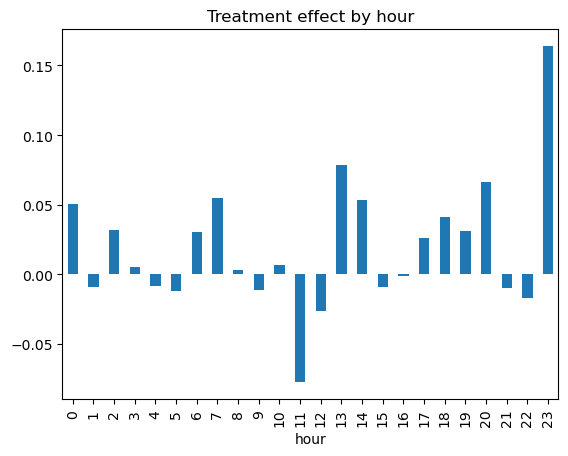

In [326]:
# Compute effect within each hour_group
hour_effects = df.groupby('hour').apply(
    lambda g: g.loc[g['dummy_experiment']==1, 'yes'].mean() - 
              g.loc[g['dummy_experiment']==0, 'yes'].mean()
)

# Weight by stratum size
weights = df['hour'].value_counts(normalize=True)
overall_effect = (hour_effects * weights).sum()

print(f"Weighted average treatment effect: {overall_effect:.2f}")
hour_effects.plot(kind='bar', title="Treatment effect by hour")

Weighted average treatment effect: 0.01


/var/folders/l1/6jvqsq8s0lz9m8sm4f3sfkbr0000gn/T/ipykernel_53188/3557894969.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  browser_effects = df.groupby('browser').apply(


<Axes: title={'center': 'Treatment effect by browser'}, xlabel='browser'>

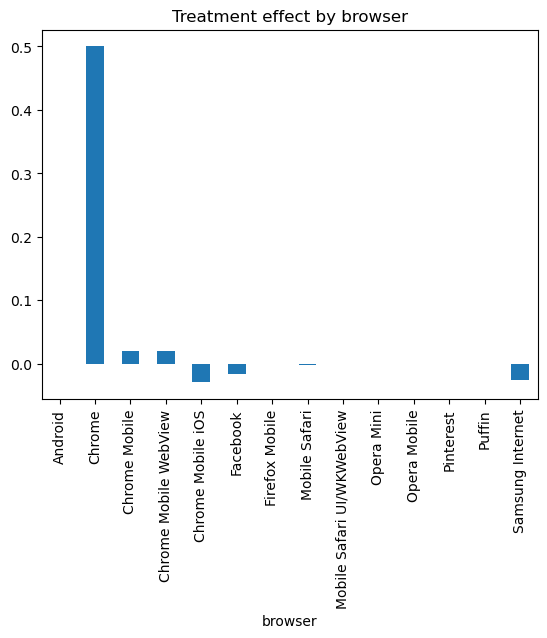

In [328]:
# Compute effect within each browser_group
browser_effects = df.groupby('browser').apply(
    lambda g: g.loc[g['dummy_experiment']==1, 'yes'].mean() - 
              g.loc[g['dummy_experiment']==0, 'yes'].mean()
)

# Weight by stratum size
weights = df['browser'].value_counts(normalize=True)
overall_effect = (browser_effects * weights).sum()

print(f"Weighted average treatment effect: {overall_effect:.2f}")
browser_effects.plot(kind='bar', title="Treatment effect by browser")

Weighted average treatment effect: 0.02


/var/folders/l1/6jvqsq8s0lz9m8sm4f3sfkbr0000gn/T/ipykernel_53188/3546150412.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  date_effects = df.groupby('date').apply(


<Axes: title={'center': 'Treatment effect by date'}, xlabel='date'>

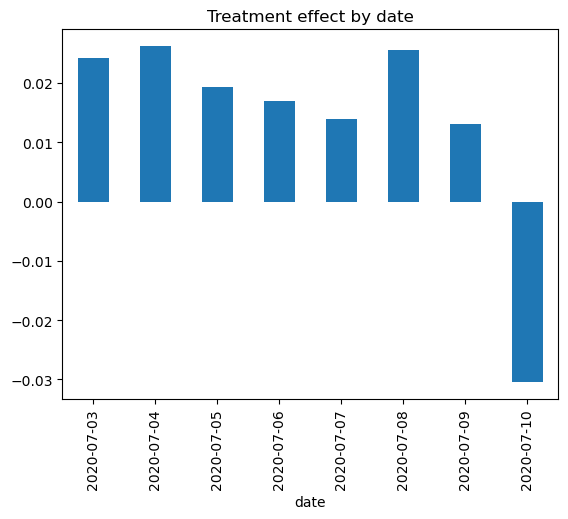

In [368]:
# Compute effect within each date_group
date_effects = df.groupby('date').apply(
    lambda g: g.loc[g['dummy_experiment']==1, 'yes'].mean() - 
              g.loc[g['dummy_experiment']==0, 'yes'].mean()
)

# Weight by stratum size
weights = df['date'].value_counts(normalize=True)
overall_effect = (date_effects * weights).sum()

print(f"Weighted average treatment effect: {overall_effect:.2f}")
date_effects.plot(kind='bar', title="Treatment effect by date")

In [364]:
model = smf.logit('yes ~ C(experiment) + C(date) + C(time_of_day)', data = df).fit()
model_1 = smf.logit('yes ~ C(experiment) + C(date) + C(time_of_day)+ C(browser) + C(platform_os)', data = df).fit()

Optimization terminated successfully.
         Current function value: 0.254764
         Iterations 7
         Current function value: 0.252096
         Iterations: 35


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [365]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    yes   No. Observations:                 8069
Model:                          Logit   Df Residuals:                     8057
Method:                           MLE   Df Model:                           11
Date:                Sat, 08 Nov 2025   Pseudo R-squ.:                0.004562
Time:                        16:18:46   Log-Likelihood:                -2055.7
converged:                       True   LL-Null:                       -2065.1
Covariance Type:            nonrobust   LLR p-value:                   0.06402
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -2.6364      0.156    -16.947      0.000      -2.941      -2.331
C(experiment)[T.exposed]        0.2107      0.093      2.256      0.024       0.028       0.394
C(date)[T.2020-07-04]           0.0251      0.158      0.158      0.874      -0.286       0.336
C(date)[T.2020-07-05]          -0.3940      0.177     -2.220      0.026      -0.742      -0.046
C(date)[T.2020-07-06]          -0.1519      0.214     -0.709      0.478      -0.572       0.268
C(date)[T.2020-07-07]          -0.0607      0.199     -0.304      0.761      -0.452       0.330
C(date)[T.2020-07-08]          -0.2400      0.160     -1.504      0.133      -0.553       0.073
C(date)[T.2020-07-09]          -0.2083      0.154     -1.349      0.177      -0.511       0.094
C(date)[T.2020-07-10]          -0.3084      0.174     -1.774      0.076      -0.649       0.032
C(time_of_day)[T.morning]       0.1625      0.135      1.203      0.229      -0.102       0.427
C(time_of_day)[T.afternoon]     0.0238      0.140      0.170      0.865      -0.251       0.298
C(time_of_day)[T.evening]       0.3305      0.162      2.041      0.041       0.013       0.648
===============================================================================================
"""

In [366]:
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    yes   No. Observations:                 8069
Model:                          Logit   Df Residuals:                     8048
Method:                           MLE   Df Model:                           20
Date:                Sat, 08 Nov 2025   Pseudo R-squ.:                 0.01499
Time:                        16:18:48   Log-Likelihood:                -2034.2
converged:                      False   LL-Null:                       -2065.1
Covariance Type:            nonrobust   LLR p-value:                 3.601e-06
============================================================================================================
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                    9.7449    959.565      0.010      0.992   -1870.968    1890.458
C(experiment)[T.exposed]                     0.1893      0.098      1.931      0.054      -0.003       0.381
C(date)[T.2020-07-04]                        0.0400      0.159      0.251      0.802      -0.272       0.353
C(date)[T.2020-07-05]                       -0.3724      0.178     -2.089      0.037      -0.722      -0.023
C(date)[T.2020-07-06]                       -0.1270      0.215     -0.590      0.555      -0.549       0.295
C(date)[T.2020-07-07]                       -0.0444      0.200     -0.222      0.825      -0.437       0.348
C(date)[T.2020-07-08]                       -0.2258      0.160     -1.413      0.158      -0.539       0.087
C(date)[T.2020-07-09]                       -0.1889      0.155     -1.219      0.223      -0.493       0.115
C(date)[T.2020-07-10]                       -0.2935      0.174     -1.685      0.092      -0.635       0.048
C(time_of_day)[T.morning]                    0.1556      0.135      1.149      0.251      -0.110       0.421
C(time_of_day)[T.afternoon]                  0.0139      0.141      0.099      0.922      -0.262       0.290
C(time_of_day)[T.evening]                    0.3218      0.162      1.982      0.047       0.004       0.640
C(browser)[T.Chrome Mobile]                 -1.8169      1.242     -1.463      0.143      -4.250       0.617
C(browser)[T.Chrome Mobile WebView]         -1.7457      1.244     -1.403      0.161      -4.184       0.693
C(browser)[T.Chrome Mobile iOS]            -13.6912    959.566     -0.014      0.989   -1894.405    1867.023
C(browser)[T.Facebook]                      -1.4795      1.247     -1.186      0.235      -3.924       0.965
C(browser)[T.Mobile Safari]                -14.1636    959.565     -0.015      0.988   -1894.877    1866.549
C(browser)[T.Mobile Safari UI/WKWebView]   -22.9381    966.377     -0.024      0.981   -1917.002    1871.126
C(browser)[T.Pinterest]                    -18.8474   1.11e+04     -0.002      0.999   -2.18e+04    2.17e+04
C(browser)[T.Samsung Internet]              -1.6272      1.247     -1.305      0.192      -4.071       0.817
C(platform_os)[T.6]                        -10.5847    959.564     -0.011      0.991   -1891.296    1870.127
============================================================================================================
"""

When controlling only for date and time of day (confounding factors), exposure to the new ad is associated with a statistically significant increase in the likelihood of responding “yes” (+0.23, p < 0.05). This effect is statistically significant when no additional variables are considered. 
However, after accounting for platform and browser differences, the effect becomes statistically insignificant, suggesting that variation in operating systems and browsers may partly explain the observed difference between groups.
Therefore, while the results provide initial evidence of a potential positive effect, they do not conclusively establish a causal impact of the new ad.
It is recommended to conduct a follow-up experiment with better balancing across browser types and time slots, and possibly a larger sample size, to validate these findings before making strategic decisions about wider campaign implementation.